In this notebook, I combine data that has been collected before the Thesis started, to compare it. This includes the Liesker-Kieft data, the 1st-year data and the vacuum data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from lmfit import Model
from scipy.stats import chi2
import math as math
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import selfmadefunctions
import importlib
importlib.reload(selfmadefunctions)
from functools import reduce

# Author: Manou Liesker. Student number: 15250946

Selfmadefuntions imported/reloaded
Selfmadefuntions imported/reloaded


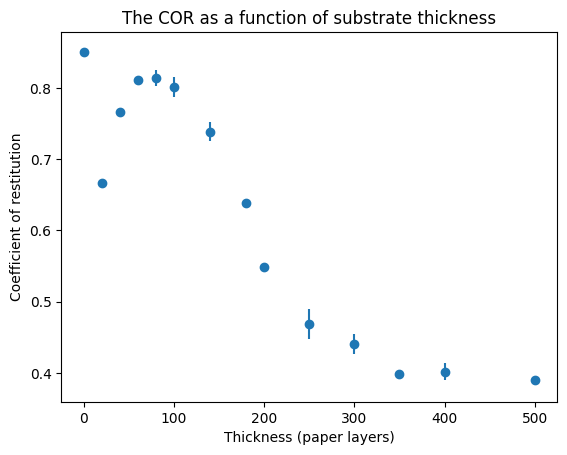

In [21]:
# Generate lists and data
NETWORK_FOLDER = Path(rf"Z:\Clean_Data\Data_Manou_Maria_Clean")
T3_Thicknesses = [0, 20, 40, 60, 80, 100, 140, 180, 200, 250, 300, 350, 400, 500]
V_Thicknesses = [0, 1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40]

# Liesker-Kieft Data
T_COR, T_COR_err = selfmadefunctions.calulate_COR(NETWORK_FOLDER, 'T3', T3_Thicknesses, 3, True) # (networkfolder, filebegin, thicknesslist, repetitions, Plot)
V_COR, V_COR_err = selfmadefunctions.calulate_COR(NETWORK_FOLDER, 'V', V_Thicknesses, 3, False)

# 1st year Data, "h"
A4_h_Thickness, A4_h_COR, A4_h_COR_err = selfmadefunctions.read_saladin_data("A4_sanitized_data.csv", False, 1)
A5_hB_Thickness, A5_hB_COR, A5_hB_COR_err = selfmadefunctions.read_saladin_data("A5_B_sanitized_data.csv", False, 1)
A5_hO_Thickness, A5_hO_COR, A5_hO_COR_err = selfmadefunctions.read_saladin_data("A5_O_sanitized_data.csv", False, 1)

# 1st year Data "v"
# I'll probably leave this out, as i don't find it a reliable way to calculate the COR. After my conversation with Saladin and Laura, I will process the data myself completely.
A4_v_Thickness, A4_v_COR, A4_v_COR_err = selfmadefunctions.read_saladin_data("A4_sanitized_data.csv", False, 3)
A5_vB_Thickness, A5_vB_COR, A5_vB_COR_err = selfmadefunctions.read_saladin_data("A5_B_sanitized_data.csv", False, 3)
A5_vO_Thickness, A5_vO_COR, A5_vO_COR_err = selfmadefunctions.read_saladin_data("A5_O_sanitized_data.csv", False, 3)


# Vacuum Data
NETWORK_FOLDER = Path(rf"Z:\Clean_Data\Data_Pressure_Clean")

_17_7_Pressure = [40, 100, 200, 410, 540, 755, 1018.5]
_17_7_COR = []
_17_7_COR_err = []

_18_7_Pressure = [40, 95, 100, 190, 200, 300, 410, 540, 775, 1018.5]
_18_7_COR = []
_18_7_COR_err = []

_22_7_Thickness = [1, 5, 10, 50, 150, 200, 250, 300]
_22_7_COR = []
_22_7_COR_err = []

for p in _17_7_Pressure:
    COR, COR_err = selfmadefunctions.calculate_COR_Vacuum(NETWORK_FOLDER, f"17-7_Results_100_{p}mbar_clean", _17_7_Pressure)
    _17_7_COR.append(COR) 
    _17_7_COR_err.append(COR_err)

for p in _18_7_Pressure:
    COR, COR_err = selfmadefunctions.calculate_COR_Vacuum(NETWORK_FOLDER, f"18-7_Results_100_{p}mbar_clean", _17_7_Pressure)
    _18_7_COR.append(COR) 
    _18_7_COR_err.append(COR_err)

for t in _22_7_Thickness:
    COR, COR_err = selfmadefunctions.calculate_COR_Vacuum(NETWORK_FOLDER, f"22-7_Results_{t}_30mbar_clean", _17_7_Pressure)
    _22_7_COR.append(COR) 
    _22_7_COR_err.append(COR_err)

I will get all lists into a results array. 

In [22]:
T_lists = [
    T3_Thicknesses,
    V_Thicknesses,
]

COR_lists = [
    T_COR,
    V_COR,
]

COR_err_lists = [
    T_COR_err,
    V_COR_err,
]

dfs = []
for i, (Thickness, COR, COR_err) in enumerate(zip(T_lists, COR_lists, COR_err_lists), start=1):
    dfs.append(pd.DataFrame({
        "Thickness": Thickness,
        f"COR_{i}": COR,
        f"COR_err_{i}": COR_err
    }))

results = reduce(lambda left, right: pd.merge(left, right, on="Thickness", how="outer"), dfs)
results = results.sort_values("Thickness").reset_index(drop=True)

# print(results)

Below I used the self made functions in selfmadefunctions.py to reprocess the data from 2024 I collected with Maria.

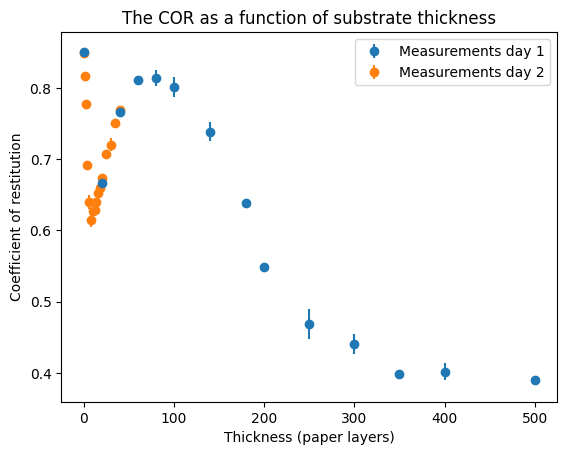

In [23]:

plt.errorbar(T3_Thicknesses, T_COR, yerr= T_COR_err, fmt = 'o', label = "Measurements day 1", zorder = 1)
plt.errorbar(V_Thicknesses, V_COR, yerr= V_COR_err, fmt = 'o', label = "Measurements day 2", zorder = 0)
plt.title('The COR as a function of substrate thickness')
plt.xlabel('Thickness (paper layers)')
plt.ylabel('Coefficient of restitution')
plt.legend()
plt.show()

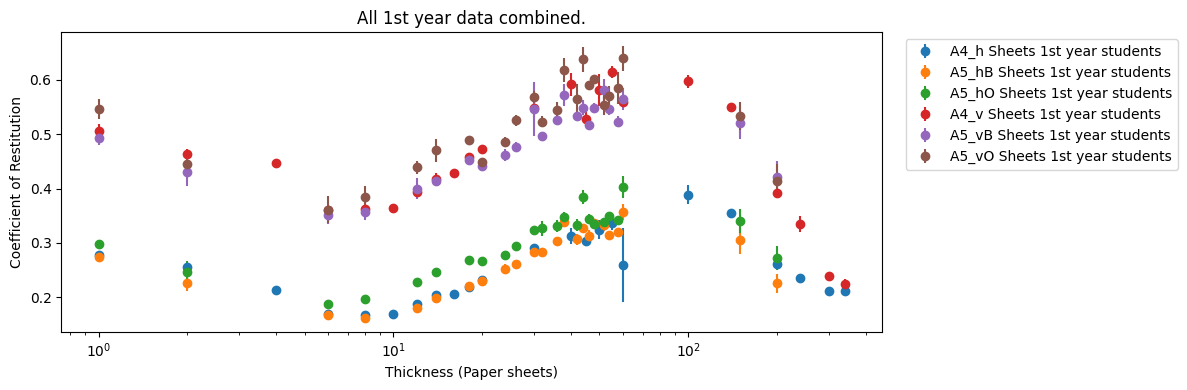

In [24]:
plt.figure(figsize = (12,4))
plt.errorbar(A4_h_Thickness, A4_h_COR, yerr = A4_h_COR_err, fmt = 'o', label = 'A4_h Sheets 1st year students')
plt.errorbar(A5_hB_Thickness, A5_hB_COR, yerr = A5_hB_COR_err, fmt = 'o', label = 'A5_hB Sheets 1st year students')
plt.errorbar(A5_hO_Thickness, A5_hO_COR, yerr = A5_hO_COR_err, fmt = 'o', label = 'A5_hO Sheets 1st year students')
plt.errorbar(A4_v_Thickness, A4_v_COR, yerr = A4_v_COR_err, fmt = 'o', label = 'A4_v Sheets 1st year students')
plt.errorbar(A5_vB_Thickness, A5_vB_COR, yerr = A5_vB_COR_err, fmt = 'o', label = 'A5_vB Sheets 1st year students')
plt.errorbar(A5_vO_Thickness, A5_vO_COR, yerr = A5_vO_COR_err, fmt = 'o', label = 'A5_vO Sheets 1st year students')
plt.title("All 1st year data combined.")
plt.xlabel("Thickness (Paper sheets)")
plt.ylabel("Coefficient of Restitution")
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

I will now recreate 1st year students graph and combine with my graph. I would like his raw data to compare our data analysis methods.

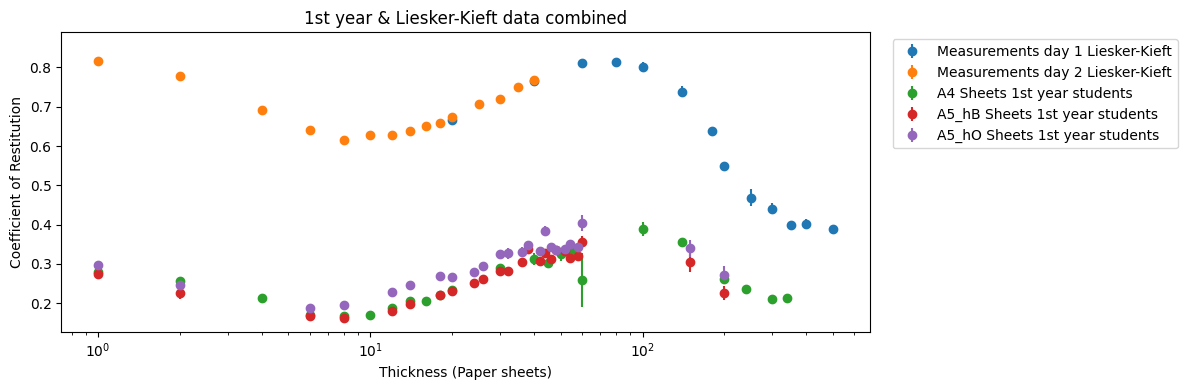

In [25]:
plt.figure(figsize = (12,4))
plt.errorbar(T3_Thicknesses, T_COR, yerr= T_COR_err, fmt = 'o', label = "Measurements day 1 Liesker-Kieft")
plt.errorbar(V_Thicknesses, V_COR, yerr= V_COR_err, fmt = 'o', label = "Measurements day 2 Liesker-Kieft")
plt.errorbar(A4_h_Thickness, A4_h_COR, yerr = A4_h_COR_err, fmt = 'o', label = 'A4 Sheets 1st year students')
plt.errorbar(A5_hB_Thickness, A5_hB_COR, yerr = A5_hB_COR_err, fmt = 'o', label = 'A5_hB Sheets 1st year students')
plt.errorbar(A5_hO_Thickness, A5_hO_COR, yerr = A5_hO_COR_err, fmt = 'o', label = 'A5_hO Sheets 1st year students')
plt.title("1st year & Liesker-Kieft data combined")
plt.xlabel("Thickness (Paper sheets)")
plt.ylabel("Coefficient of Restitution")
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

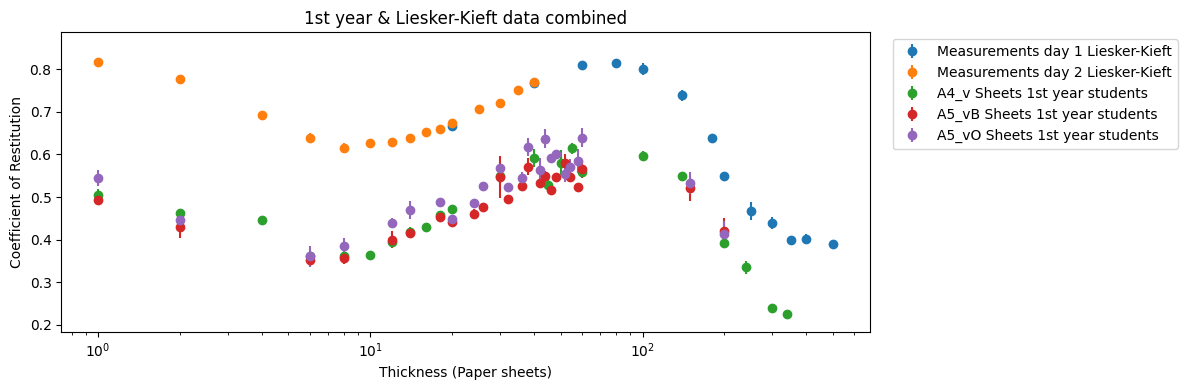

In [26]:
plt.figure(figsize = (12,4))
plt.errorbar(T3_Thicknesses, T_COR, yerr= T_COR_err, fmt = 'o', label = "Measurements day 1 Liesker-Kieft")
plt.errorbar(V_Thicknesses, V_COR, yerr= V_COR_err, fmt = 'o', label = "Measurements day 2 Liesker-Kieft")
plt.errorbar(A4_v_Thickness, A4_v_COR, yerr = A4_v_COR_err, fmt = 'o', label = 'A4_v Sheets 1st year students')
plt.errorbar(A5_vB_Thickness, A5_vB_COR, yerr = A5_vB_COR_err, fmt = 'o', label = 'A5_vB Sheets 1st year students')
plt.errorbar(A5_vO_Thickness, A5_vO_COR, yerr = A5_vO_COR_err, fmt = 'o', label = 'A5_vO Sheets 1st year students')
plt.title("1st year & Liesker-Kieft data combined")
plt.xlabel("Thickness (Paper sheets)")
plt.ylabel("Coefficient of Restitution")
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Here are the experiments done in a vacuum chamber. I'd like to repeate these measurements with 3 or more repetitions per  thickness/pressure, so we cam get clearer data. I am not aware of the errors on the measurements.

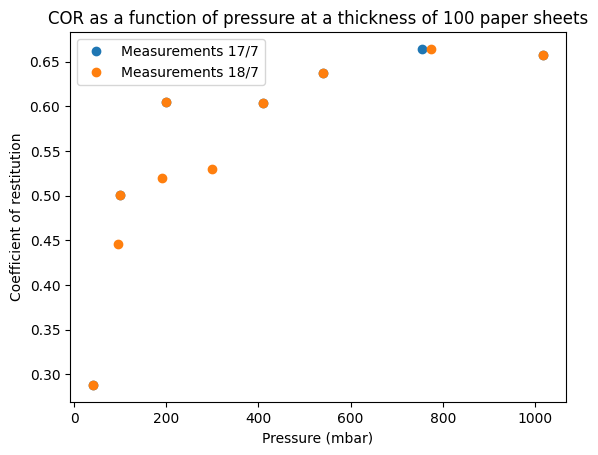

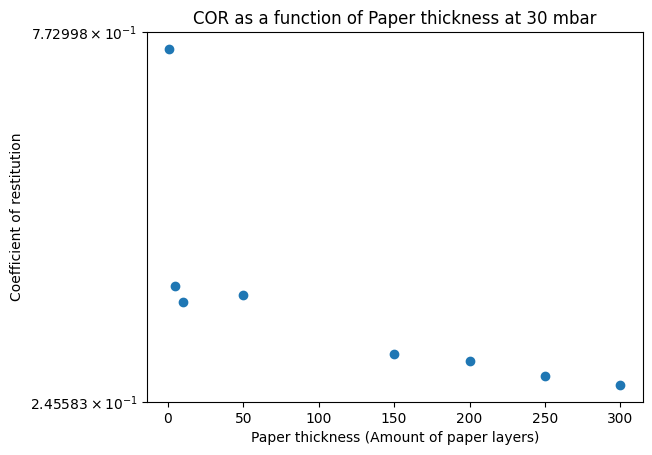

[1, 5, 10, 50, 150, 200, 250, 300] [np.float64(0.7490242156719825), np.float64(0.4100769816881989), np.float64(0.3873082483746165), np.float64(0.3980873329778875), np.float64(0.3136401541306563), np.float64(0.3038086052841181), np.float64(0.2824805975164077), np.float64(0.26955684133073443)]


In [ ]:
plt.errorbar(_17_7_Pressure, _17_7_COR, label = 'Measurements 17/7', fmt = 'o')
plt.errorbar(_18_7_Pressure, _18_7_COR, label = 'Measurements 18/7', fmt = 'o')
plt.title("COR as a function of pressure at a thickness of 100 paper sheets")
plt.xlabel("Pressure (mbar)")
plt.ylabel("Coefficient of restitution")
plt.legend()
plt.show()

plt.errorbar(_22_7_Thickness, _22_7_COR, fmt = 'o')
plt.title("COR as a function of Paper thickness")
plt.xlabel("Paper thickness (Amount of paper layers)")
plt.ylabel("Coefficient of restitution")
plt.yscale("symlog")
plt.show()



In [61]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\80d_newpaper")

variable_type = "Number of Papers"
Thickness_80d_newpaper_unique = [0, 1, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 250, 300] 
Thickness_80d_newpaper = []
COR_80d_newpaper = []
Thickness_80d_newpaper_mm = []


for t in Thickness_80d_newpaper_unique:
    Thickness_80d_newpaper_mm.append(t * 0.1)

for t in Thickness_80d_newpaper_unique:
    variable_value = f"{t} papers"
    
    for j in range(1, 4):
        filename = f"80d_newpaper_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_80d_newpaper.append(cor_value)
        Thickness_80d_newpaper.append(t)

COR_80d_newpaper [30] = np.nan


Thickness_80d_newpaper, COR_80d_newpaper, COR_err_80d_newpaper, avg_COR_80d_newpaper, Thickness_80d_newpaper_unique = selfmadefunctions.get_avg_err(Thickness_80d_newpaper, COR_80d_newpaper)



importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\160density")

variable_type = "Number of Papers"
Thickness_160d_unique = [1, 2, 3, 4, 5, 10, 20, 50, 100, 150, 200, 250] 
Thickness_160d = []
COR_160d = []
Thickness_160d_mm = []

for t in Thickness_160d_unique:
    variable_value = f"{t} papers"
    
    for j in range(1, 4):
        filename = f"160d_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_160d.append(cor_value)
        Thickness_160d.append(t)


for t in Thickness_160d_unique:
    Thickness_160d_mm.append(t * 0.15)

Thickness_160d, COR_160d, COR_err_160d, avg_COR_160d, Thickness_160d_unique = selfmadefunctions.get_avg_err(Thickness_160d, COR_160d)

Selfmadefuntions imported/reloaded
Selfmadefuntions imported/reloaded


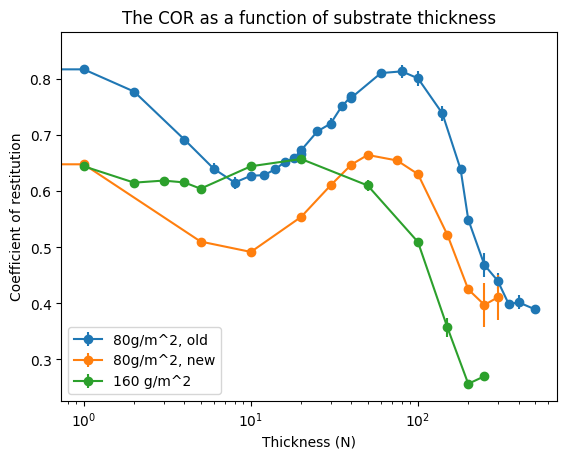

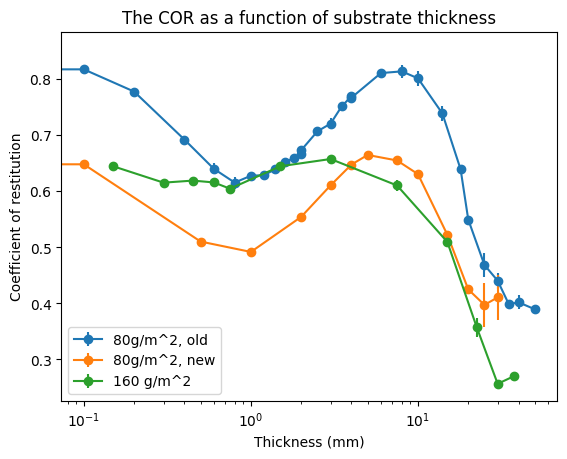

In [62]:
d80_oldpaper_N = np.array(V_Thicknesses + T3_Thicknesses)
d80_oldpaper_COR = np.array(V_COR + T_COR)
d80_oldpaper_COR_err = np.array (V_COR_err + T_COR_err)

order = np.argsort(d80_oldpaper_N)

d80_old_N_sorted = d80_oldpaper_N[order]
d80_old_COR_sorted = d80_oldpaper_COR[order]
d80_old_COR_err_sorted = d80_oldpaper_COR_err[order]

d80_old_mm = []

for t in d80_old_N_sorted:
    d80_old_mm.append(t * 0.1)


plt.errorbar(d80_old_N_sorted, d80_old_COR_sorted, yerr= d80_old_COR_err_sorted, fmt = '-o', label = "80g/m^2, old")
plt.errorbar(Thickness_80d_newpaper_unique, avg_COR_80d_newpaper, yerr = COR_err_80d_newpaper, fmt = '-o', label = "80g/m^2, new")
plt.errorbar(Thickness_160d_unique, avg_COR_160d, yerr = COR_err_160d, fmt = '-o', label = '160 g/m^2')
plt.title('The COR as a function of substrate thickness')
plt.xlabel('Thickness (N)')
plt.ylabel('Coefficient of restitution')
plt.xscale('log')
plt.legend()
plt.show()

plt.errorbar(d80_old_mm, d80_old_COR_sorted, yerr= d80_old_COR_err_sorted, fmt = '-o', label = "80g/m^2, old")
plt.errorbar(Thickness_80d_newpaper_mm, avg_COR_80d_newpaper, yerr = COR_err_80d_newpaper, fmt = '-o', label = "80g/m^2, new")
plt.errorbar(Thickness_160d_mm, avg_COR_160d, yerr = COR_err_160d, fmt = '-o', label = '160 g/m^2')
plt.title('The COR as a function of substrate thickness')
plt.xlabel('Thickness (mm)')
plt.ylabel('Coefficient of restitution')
plt.xscale('log')
plt.legend()
plt.show()

I showed my original COR graph (The one that started it all!) to a friend of mine, who said he recognised it from somewhere. Later he sent me the Weibull distribution and with the help of chatgpt I threw together a quick fit to fit it to the data. Now, this is probably just a coincidence, since I'm having a hard time connecting the mathemathical model of a Weibull distribution to the experiment I am conducting, but it's a striking similarity nonetheless.

[np.float64(0.003893298903567806), np.float64(0.002344043888431038), np.float64(0.0020422001181483094), np.float64(0.002647343774053268), np.float64(0.010940316469857297), np.float64(0.013537216493383417), np.float64(0.013691598770602298), np.float64(0.0008362212470834447), np.float64(0.0050940955967126375), np.float64(0.021234616312319404), np.float64(0.014079200953654477), np.float64(0.0015715772544463232), np.float64(0.012147128290887255), np.float64(0.006259485052877045)]
[0.0038933  0.00234404 0.0020422  0.00264734 0.01094032 0.01353722
 0.0136916  0.00083622 0.0050941  0.02123462 0.0140792  0.00157158
 0.01214713 0.00625949]


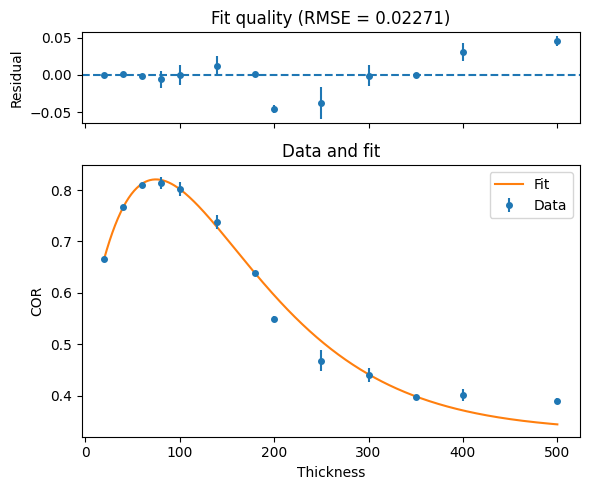

[[Model]]
    Model(fit_function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 143
    # data points      = 13
    # variables        = 4
    chi-square         = 147.401843
    reduced chi-square = 16.3779825
    Akaike info crit   = 39.5667706
    Bayesian info crit = 41.8265680
    R-squared          = 0.98099569
[[Variables]]
    l:   75.2427591 +/- 7.18920378 (9.55%) (init = 96)
    t0: -17.2731561 +/- 9.26575098 (53.64%) (init = -28)
    k:   2.22265505 +/- 0.25662145 (11.55%) (init = 2)
    A:   44.1255853 +/- 11.4745098 (26.00%) (init = 0.81364)
[[Correlations]] (unreported correlations are < 0.100)
    C(k, A)  = -0.9989
    C(l, A)  = +0.9787
    C(l, k)  = -0.9713
    C(t0, k) = -0.9633
    C(t0, A) = +0.9532
    C(l, t0) = +0.8767


In [30]:
# --------------------------------------------------
# Input data: convert to clean numpy arrays
# --------------------------------------------------
t_data = np.asarray(T3_Thicknesses, dtype=float)
y_data = np.asarray(T_COR, dtype=float)

# If you intentionally want to skip the first point:
t_data = t_data[1:]
y_data = y_data[1:]

# Remove NaN/inf just in case
mask = np.isfinite(t_data) & np.isfinite(y_data)
t_data = t_data[mask]
y_data = y_data[mask]

print(T_COR_err)
err_data = np.asarray(T_COR_err, dtype=float)
print(err_data)

# apply the same slicing as the data
err_data = err_data[1:]

# apply the same finite-data mask
err_data = err_data[mask]

# avoid division by zero or negative uncertainties
err_data = np.where(err_data <= 0, np.nan, err_data)

weights = 1.0 / err_data

if len(t_data) < 3:
    raise ValueError("Not enough valid data points left to fit.")

# --------------------------------------------------
# Model function
# Shifted gamma-like curve
# For t <= t0, return 0 to avoid invalid fractional powers
# --------------------------------------------------
def fit_function(t, l, t0, k, A):
    x = (t - t0) / l
    y = np.zeros_like(x, dtype=float)

    positive = x > 0
    y[positive] = A * (k / l) * (x[positive] ** (k - 1)) * np.exp(-x[positive]) + 0.33

    return y

calibration_model = Model(fit_function)

# --------------------------------------------------
# Reasonable initial guesses
# --------------------------------------------------
A_guess = np.nanmax(y_data) if np.nanmax(y_data) > 0 else 1.0
t0_guess = np.nanmin(t_data) - 0.1 * (np.nanmax(t_data) - np.nanmin(t_data))
l_guess = max((np.nanmax(t_data) - np.nanmin(t_data)) / 5, 1e-3)
k_guess = 2.0

params = calibration_model.make_params(
    l=l_guess,
    t0=t0_guess,
    k=k_guess,
    A=A_guess,
)

# Bounds to keep the fit sane
params["l"].set(min=1e-6)
params["k"].set(min=1e-6, max=20)
params["t0"].set(min=np.nanmin(t_data) - 2 * (np.nanmax(t_data) - np.nanmin(t_data)),
                 max=np.nanmax(t_data))
params["A"].set(min=0)


# --------------------------------------------------
# Fit
# --------------------------------------------------
fit_result = calibration_model.fit(
    y_data,
    params=params,
    t=t_data,
    weights=weights
)

# Best fit on measured x values
fit_y = fit_result.best_fit
residuals = y_data - fit_y
rmse = np.sqrt(np.mean(residuals**2))

# Smooth curve for plotting
t_fine = np.linspace(np.min(t_data), np.max(t_data), 500)
fit_fine = fit_result.eval(t=t_fine)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, (ax_res, ax_main) = plt.subplots(
    2, 1,
    figsize=(6, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# Residual plot
ax_res.axhline(0, linestyle="--")
ax_res.errorbar(t_data, residuals, yerr= T_COR_err[1:], fmt="o", markersize=4)
ax_res.set_ylabel("Residual")
ax_res.set_title(f"Fit quality (RMSE = {rmse:.4g})")

# Main plot
ax_main.errorbar(t_data, y_data, yerr= T_COR_err[1:], fmt="o", markersize=4, label="Data", zorder=2)
ax_main.plot(t_fine, fit_fine, label="Fit", zorder=1)

ax_main.set_xlabel("Thickness")
ax_main.set_ylabel("COR")
ax_main.set_title("Data and fit")
ax_main.legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Print fit report
# --------------------------------------------------
print(fit_result.fit_report())

As I've been looking into it, I found there's a lot of probability distributions that look like they could fit quite nicely to the data I collected. The problem is that my data is not a probability distribution, so it's hard to explain why my data would fit to those models so well. 

The most probable way I will be able to model the behaviour mathematically is by splitting the data up into three regimes, and finding a formula for each and a "dominating physical effect". This doesn't prevent me from trying to fit every distribution that even kind of looks like the data in hopes I make some sort of amazing breakthrough (Nobel Prize, here I come).

I suppose there is a chance the data we're studying is some sort of asymmetric Gaussian (at least, the second and third regime fitted above). Why that is, is a mystery to me.

I might have a good fit. Lets say each paper DOES decrease the amount of COR with the 1/x type of behaviour that i predicted all the way back in 2024. This only doesn't account for one thing: when there's a few paper sheets, the ball has a hard impact with the hard substrate, losing energy. The more papers you put on, the more the ball gets shielded. This gives the sudden jump in COR at 10 paper sheets: thats the point at which the ball doesnt hit the paper anymore. I made a function with two behaviours: The 1/x behaviour of each paper, and the sudden jump of shielding. I will now fit that curve to the datapoints.

[  0.   0.   1.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  20.
  25.  30.  35.  40.  40.  60.  80. 100. 140. 180. 200. 250. 300. 350.
 400. 500.] [0.85084165 0.84835318 0.81723585 0.77757    0.69203222 0.63986294
 0.61530286 0.62751496 0.62853453 0.63922296 0.65215445 0.65886402
 0.67302191 0.66639673 0.7066585  0.72046499 0.75146693 0.76930074
 0.76683297 0.81057271 0.81364002 0.80123775 0.73860656 0.63898313
 0.54935587 0.46832733 0.44029524 0.39823284 0.40179951 0.38944457]
[[Model]]
    Model(combined_curve)
[[Fit Statistics]]
    # fitting method   = least_squares
    # function evals   = 60
    # data points      = 30
    # variables        = 4
    chi-square         = 64650.9668
    reduced chi-square = 2486.57565
    Akaike info crit   = 238.266829
    Bayesian info crit = 243.871618
    R-squared          = 0.47833099
[[Variables]]
    b:   60.0000000 +/- 50.2960092 (83.83%) (init = 25)
    d:   0.69976847 +/- 0.46712128 (66.75%) (init = 0.4)
    k:   0.09899188 +/- 0.

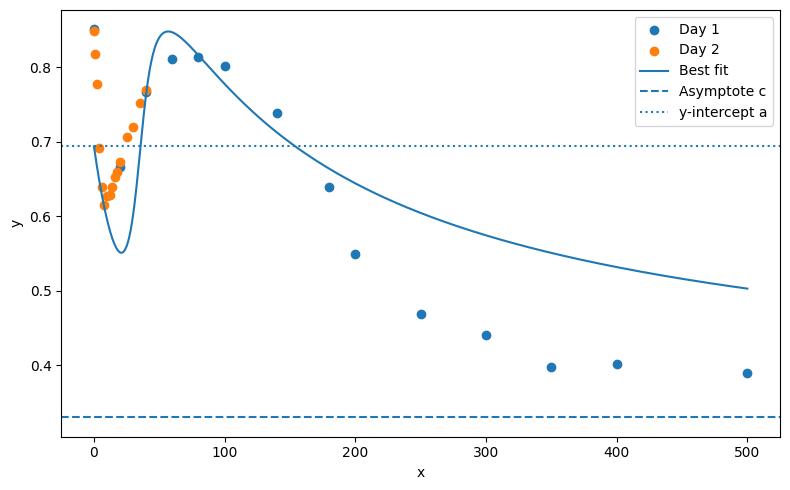

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model

# ============================================================
# 1. PUT YOUR TWO DATASETS HERE
# ============================================================

# Example placeholders - replace these with your actual data
x_day1 = T3_Thicknesses
y_day1 = T_COR

x_day2 = V_Thicknesses
y_day2 = V_COR

# ============================================================
# 2. FIXED CONSTANTS
#    a = y-intercept
#    c = total right asymptote
# ============================================================

a = 0.6938   # replace with your known y-intercept
c = 0.33   # replace with your known asymptote

# ============================================================
# 3. COMBINE THE TWO DATASETS
# ============================================================

x_all = np.array(x_day1 + x_day2, dtype=float)
y_all = np.array(y_day1 + y_day2, dtype=float)

# Optional but usually nice: sort by x after combining
sort_idx = np.argsort(x_all)
x_all = x_all[sort_idx]
y_all = y_all[sort_idx]

print(x_all, y_all)

# ============================================================
# 4. DEFINE THE MODEL
# ============================================================

def combined_curve(x, b, d, k, x0, n):
    """
    Model:
    f(x) = (c-d) + ((a-(c-d))*b)/(x+b)
           + d*(arctan(k*(x-x0)) + arctan(2**k*x0)) / (pi/2 + arctan(k*x0))

    where a and c are fixed constants from outside the function.
    """
    N = np.pi / 2 + np.arctan(k * x0)
    f1 = (c - d) + ((a - (c - d))) / (x/b + 1)**n
    f2 = d * (np.arctan(k * (x - x0)) + np.arctan(k * x0)) / N
    return f1 + f2

model = Model(combined_curve)

# ============================================================
# 5. INITIAL GUESSES
#    Adjust these if needed
# ============================================================

params = model.make_params()

params["b"].set(value=25, min=5, max=60)
params["d"].set(value=0.4, min=0.02, max=1)
params["k"].set(value=0.05, min=0.005, max=0.12)
params["x0"].set(value=35, vary = False)
params["n"].set(value=1.1, min=0.8, max=1.4)



# ============================================================
# 7. FIT
# ============================================================
yerr_all = np.array(T_COR_err + V_COR_err, dtype=float)[sort_idx]
weights = 1 / yerr_all
result = model.fit(y_all,params,x=x_all,weights = weights, method="least_squares", max_nfev=20000)

# ============================================================
# 8. PRINT RESULTS
# ============================================================

print(result.fit_report())

# ============================================================
# 9. PLOT
# ============================================================

x_fit = np.linspace(np.min(x_all), np.max(x_all), 1000)
y_fit = result.eval(x=x_fit)

plt.figure(figsize=(8, 5))
plt.scatter(x_day1, y_day1, label="Day 1")
plt.scatter(x_day2, y_day2, label="Day 2")
plt.plot(x_fit, y_fit, label="Best fit")
plt.axhline(c, linestyle="--", label="Asymptote c")
plt.axhline(a, linestyle=":", label="y-intercept a")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()


okay so that doesn't work

In [3]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\80d_newpaper")

variable_type = "Number of Papers"
Thickness_80d_newpaper_unique = [0, 1, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 250, 300] 
Thickness_80d_newpaper = []
COR_80d_newpaper = []
Thickness_80d_newpaper_mm = []

for t in Thickness_80d_newpaper_unique:
    variable_value = f"{t} papers"
    
    for j in range(1, 4):
        filename = f"80d_newpaper_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_3(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_80d_newpaper.append(cor_value)
        Thickness_80d_newpaper.append(t)

COR_80d_newpaper [30] = np.nan


Thickness_80d_newpaper, COR_80d_newpaper, COR_err_80d_newpaper, avg_COR_80d_newpaper, Thickness_80d_newpaper_unique = selfmadefunctions.get_avg_err(Thickness_80d_newpaper, COR_80d_newpaper)



for t in Thickness_80d_newpaper_unique:
    Thickness_80d_newpaper_mm.append(t * 0.1)


inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\80density")

variable_type = "Number of Papers"
Thickness_80d_unique = [0, 1, 5, 10, 20, 30, 40, 60, 80, 100, 120]
Thickness_80d = []
COR_80d = []
Thickness_80d_mm = []

for t in Thickness_80d_unique:
    variable_value = f"{t} papers"
    
    for j in range(1, 4):
        filename = f"80d_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_3(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_80d.append(cor_value)
        Thickness_80d.append(t)

Thickness_80d, COR_80d, COR_err_80d, avg_COR_80d, Thickness_80d_unique = selfmadefunctions.get_avg_err(Thickness_80d, COR_80d)

for t in Thickness_80d_unique:
    Thickness_80d_mm.append(t * 0.1)


inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\160density")

variable_type = "amount of paper sheets"
Thickness_160d_unique = [1, 5, 10, 15, 20, 50, 100, 150, 200, 250, 300, 400, 500]
Thickness_160d = []
COR_160d = []
Thickness_160d_mm = []


for t in Thickness_160d_unique:
    variable_value = f"{t} paper sheets"
    
    for i in range(1, 4):
        filename = f"160d_{t}t_{i}_clean"
        cor_value = selfmadefunctions.COR_calculator_3(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_160d.append(cor_value)
        Thickness_160d.append(t)

Thickness_160d, COR_160d, COR_err_160d, avg_COR_160d, Thickness_160d_unique = selfmadefunctions.get_avg_err(Thickness_160d, COR_160d)

for t in Thickness_160d_unique:
    Thickness_160d_mm.append(t * 0.15)


inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\120density")

variable_type = "distance from edge"
Thickness_120d_unique = [0, 1, 5, 10, 20, 30, 40, 50, 75, 100, 125, 150, 200]
Thickness_120d = []
COR_120d = []
Thickness_120d_mm = []


for t in Thickness_120d_unique:
    variable_value = f"{t} sheets"
    
    for j in range(1, 4):
        filename = f"120d_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_3(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_120d.append(cor_value)
        Thickness_120d.append(t)

Thickness_120d, COR_120d, COR_err_120d, avg_COR_120d, Thickness_unique_120d = selfmadefunctions.get_avg_err(Thickness_120d, COR_120d)

for t in Thickness_120d_unique:
    Thickness_120d_mm.append(t * 0.15)


inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\40density")
variable_type = "Amount of paper layers"
Thickness_40d_unique = [0, 1, 2, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 250, 300, 350, 400, 425, 450, 500]
Thickness_40d = []
COR_40d = []
Thickness_40d_mm = []


for t in Thickness_40d_unique:
    variable_value = f"{t} sheets"
    
    for j in range(1, 4):
        filename = f"40d_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_3(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_40d.append(cor_value)
        Thickness_40d.append(t)

Thickness_40d, COR_40d, COR_err_40d, avg_COR_40d, Thickness_unique_40d = selfmadefunctions.get_avg_err(Thickness_40d, COR_40d)

for t in Thickness_40d_unique:
    Thickness_40d_mm.append(t * 0.05)


importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\120density_white")

variable_type = "Amount of paper layers"
Thickness_120dw_unique = [0, 1, 3, 5, 7, 10, 15, 20, 30, 40, 50, 75, 100, 125, 150, 200, 250,  300, 350, 400, 450, 500]
Thickness_120dw = []
COR_120dw = []
Thickness_120dw_mm = []


for t in Thickness_120dw_unique:
    variable_value = f"{t} sheets"
    
    for j in range(1, 6):
        filename = f"120dw_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_3(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_120dw.append(cor_value)
        Thickness_120dw.append(t)

for t in Thickness_120dw_unique:
    Thickness_120dw_mm.append(t * 0.15)

Thickness_120dw, COR_120dw, COR_err_120dw, avg_COR_120dw, Thickness_unique_120dw = selfmadefunctions.get_avg_err(Thickness_120dw, COR_120dw)


importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\250density")

variable_type = "Amount of paper layers"
Thickness_250d_unique = [0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 25, 33, 40, 50, 60, 80, 100, 125, 150, 200, 250, 300, 350, 400, 450, 500]
Thickness_250d = []
COR_250d = []
Thickness_250d_mm = [] 


for t in Thickness_250d_unique:
    variable_value = f"{t} sheets"
    
    for j in range(1, 6):
        filename = f"250d_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_3(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_250d.append(cor_value)
        Thickness_250d.append(t)

Thickness_250d, COR_250d, COR_err_250d, avg_COR_250d, Thickness_unique_250d = selfmadefunctions.get_avg_err(Thickness_250d, COR_250d)

for t in Thickness_250d_unique:
    Thickness_250d_mm.append(t * 0.22)

Selfmadefuntions imported/reloaded
Selfmadefuntions imported/reloaded
Selfmadefuntions imported/reloaded


In [6]:
# Generate normalized data
COR_substrate = (COR_80d[0] + COR_80d_newpaper[0]) / 2

normalized_COR_160d = []
normalized_COR_80d = []
normalized_COR_80d_newpaper = []
normalized_shifted_160d = []

for t in avg_COR_160d:
    normalized_COR_160d.append(t/COR_substrate)

for t in avg_COR_80d:
    normalized_COR_80d.append(t/COR_substrate)

for t in avg_COR_80d_newpaper:
    normalized_COR_80d_newpaper.append(t/COR_substrate)


#Translate data
Thickness_shifted_160d = []
COR_shifted_160d = []

for t in Thickness_160d_unique:
    Thickness_shifted_160d.append(t * 4)

for t in normalized_COR_160d:
    COR_shifted_160d.append(t ** (4/3))



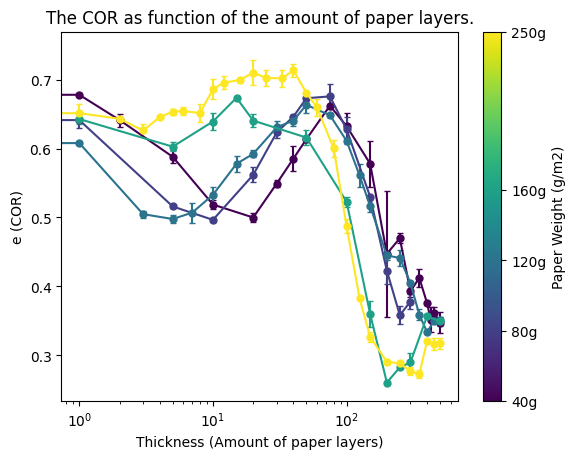

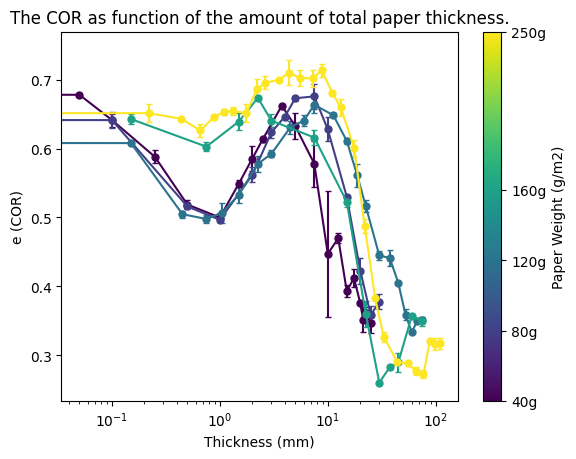

In [4]:
# 1. Define your paper weights
weights = [40, 80, 120, 160, 250]

# 2. Normalize weights range for the colormap (LogNorm handles exponential scaling well)
norm = mpl.colors.Normalize(vmin=min(weights), vmax=max(weights))
cmap = plt.colormaps['viridis']  # Try 'plasma', 'inferno', 'coolwarm', or 'copper'

# --- PLOT 1: Function of the amount of paper layers ---
fig1, ax1 = plt.subplots()

ax1.errorbar(Thickness_unique_40d, avg_COR_40d, yerr=COR_err_40d, fmt='o-',
            color=cmap(norm(40)), markersize=5, capsize=2, label='40 g/m2, new paper')

ax1.errorbar(Thickness_80d_newpaper_unique, avg_COR_80d_newpaper, yerr=COR_err_80d_newpaper, fmt='o-',
            color=cmap(norm(80)), markersize=5, capsize=2, label='80 g/m2, new paper')

ax1.errorbar(Thickness_unique_120dw, avg_COR_120dw, yerr=COR_err_120dw, fmt='o-',
            color=cmap(norm(120)), markersize=5, capsize=2, label='120 g/m2, new paper')

ax1.errorbar(Thickness_160d_unique, avg_COR_160d, yerr=COR_err_160d, fmt='o-',
            color=cmap(norm(160)), markersize=5, capsize=2, label='160 g/m2, new paper')

ax1.errorbar(Thickness_unique_250d, avg_COR_250d, yerr=COR_err_250d, fmt='o-',
            color=cmap(norm(250)), markersize=5, capsize=2, label='160 g/m2, new paper')



ax1.set_ylabel("e (COR)")
ax1.set_xlabel("Thickness (Amount of paper layers)")
ax1.set_xscale('log')
ax1.set_title("The COR as function of the amount of paper layers.")

# Colorbar for Plot 1
sm1 = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm1.set_array([])
cbar1 = fig1.colorbar(sm1, ax=ax1)
cbar1.set_label('Paper Weight (g/m2)')
cbar1.set_ticks(weights)
cbar1.set_ticklabels([f'{w}g' for w in weights])

plt.show()


# --- PLOT 2: Function of total paper thickness (mm) ---
fig2, ax2 = plt.subplots()

ax2.errorbar(Thickness_40d_mm, avg_COR_40d, yerr=COR_err_40d, fmt='o-',
            color=cmap(norm(40)), markersize=5, capsize=2, label='40 g/m2, new paper')

ax2.errorbar(Thickness_80d_newpaper_mm, avg_COR_80d_newpaper, yerr=COR_err_80d_newpaper, fmt='o-',
            color=cmap(norm(80)), markersize=5, capsize=2, label='80 g/m2, new paper')

ax2.errorbar(Thickness_120dw_mm, avg_COR_120dw, yerr=COR_err_120dw, fmt='o-',
            color=cmap(norm(120)), markersize=5, capsize=2, label='120 g/m2, new paper')

ax2.errorbar(Thickness_160d_mm, avg_COR_160d, yerr=COR_err_160d, fmt='o-',
            color=cmap(norm(160)), markersize=5, capsize=2, label='160 g/m2, new paper')

ax2.errorbar(Thickness_250d_mm, avg_COR_250d, yerr=COR_err_250d, fmt='o-',
            color=cmap(norm(250)), markersize=5, capsize=2, label='160 g/m2, new paper')


ax2.set_ylabel("e (COR)")
ax2.set_xlabel("Thickness (mm)")
ax2.set_xscale('log')
ax2.set_title("The COR as function of the amount of total paper thickness.")

# Colorbar for Plot 2
sm2 = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm2.set_array([])
cbar2 = fig2.colorbar(sm2, ax=ax2)
cbar2.set_label('Paper Weight (g/m2)')
cbar2.set_ticks(weights)
cbar2.set_ticklabels([f'{w}g' for w in weights])

plt.show()


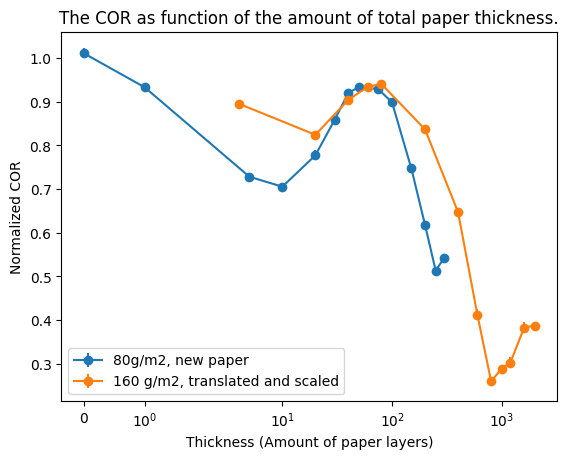

In [67]:
plt.errorbar(Thickness_80d_newpaper_unique, normalized_COR_80d_newpaper, yerr = COR_err_80d_newpaper, fmt = 'o-', label = '80g/m2, new paper')
plt.errorbar(Thickness_shifted_160d, COR_shifted_160d, yerr = COR_err_160d, fmt = 'o-', label = '160 g/m2, translated and scaled')
plt.ylabel("Normalized COR")
plt.xlabel("Thickness (Amount of paper layers)")
plt.title("The COR as function of the amount of total paper thickness.")
plt.xscale('symlog')
plt.legend()
plt.show()

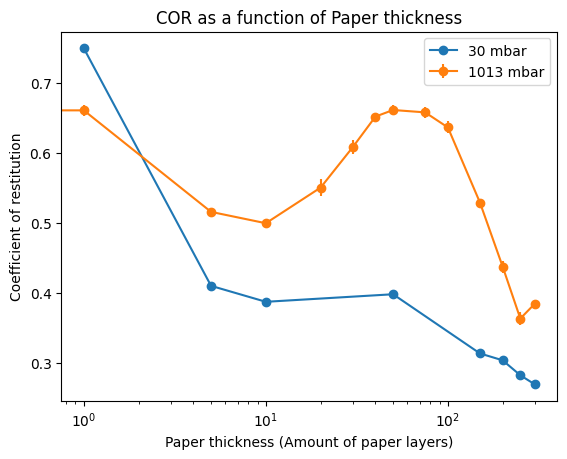

[1, 5, 10, 50, 150, 200, 250, 300] [np.float64(0.7490242156719825), np.float64(0.4100769816881989), np.float64(0.3873082483746165), np.float64(0.3980873329778875), np.float64(0.3136401541306563), np.float64(0.3038086052841181), np.float64(0.2824805975164077), np.float64(0.26955684133073443)]
[[Model]]
    Model(fit_function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 53
    # data points      = 8
    # variables        = 3
    chi-square         = 32.4308228
    reduced chi-square = 6.48616456
    Akaike info crit   = 17.1973420
    Bayesian info crit = 17.4356666
    R-squared          = 0.92310249
[[Variables]]
    a:  0.91795786 +/- 0.11038451 (12.03%) (init = 1)
    b: -0.33839390 +/- 0.12000450 (35.46%) (init = -2)
    c:  0.31961713 +/- 0.02201716 (6.89%) (init = 0.2)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.7685
    C(b, c) = -0.4054
    C(a, c) = +0.1926
bounce height = -0.3383938999465812 pixels
RMSE = 0.04 pixel

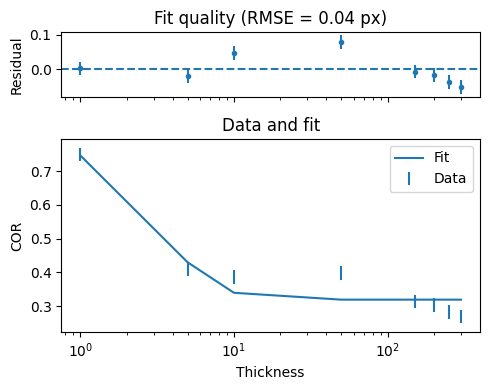

In [68]:
plt.errorbar(_22_7_Thickness, _22_7_COR, fmt = 'o-', label = '30 mbar')
plt.title("COR as a function of Paper thickness")
plt.errorbar(Thickness_80d_newpaper_unique, avg_COR_80d_newpaper, yerr = COR_err_80d_newpaper, fmt = 'o-', label = '1013 mbar')
plt.xlabel("Paper thickness (Amount of paper layers)")
plt.ylabel("Coefficient of restitution")
plt.yscale('linear')
plt.xscale('log')
plt.legend()
plt.show()

print(_22_7_Thickness, _22_7_COR)

y_points =_22_7_COR
frames = _22_7_Thickness
def fit_function(t, a, b, c):
    return (a-c) * np.exp(b * t) + c


calibration_model = Model(fit_function)
calibration_model.set_param_hint('a', min = 0.01, max = 4)
calibration_model.set_param_hint('b', min =-20, max = -0.01)
calibration_model.set_param_hint('c', min = 0.01, max = 0.5)

fit_result = calibration_model.fit(y_points, t=frames, a=1, b=-2, c = 0.2, weights=1/0.02)
a = fit_result.params['a'].value
b = fit_result.params['b'].value


print(fit_result.fit_report())

fit_y = fit_result.best_fit
residuals = y_points - fit_y
rmse = np.sqrt(np.mean(residuals**2))

fig, (ax_res, ax_main) = plt.subplots(
    2, 1, figsize=(5, 4), sharex=True,
    gridspec_kw={'height_ratios': [1, 3]}
)

print(f'bounce height = {b} pixels')
print(f'RMSE = {rmse:.2f} pixels')

# residual plot
ax_res.axhline(0, linestyle='--')
ax_res.errorbar(frames, residuals, yerr = 0.02, fmt = 'o', markersize=3)
ax_res.set_ylabel('Residual')
ax_res.set_title(f'Fit quality (RMSE = {rmse:.2f} px)')

# main plot
ax_main.errorbar(frames, y_points, label='Data', yerr=0.02, fmt='None', markersize=1, zorder=2)
ax_main.plot(frames, fit_y, label='Fit', zorder=1)


ax_main.set_xlabel('Thickness')
ax_main.set_ylabel('COR')
ax_main.set_title('Data and fit')
ax_main.set_xscale('log')
ax_main.legend()

plt.tight_layout()
plt.show()
